# 🌾 [Crop Yield agriculture](https://www.kaggle.com/datasets/samuelotiattakorah/agriculture-crop-yield/data)

This dataset is designed to analyze **crop yield** (in tons per hectare) based on a variety of environmental and agricultural factors. It includes **1,000,000 samples** and **10 features**. Here's a summary of the structure:

- **Categorical Columns**:
  - 🌍 **Region**: The geographical area where crops are grown (e.g., North, East).
  - 🌱 **Soil_Type**: Type of soil used for planting (e.g., Clay, Sandy, Loam).
  - 🌾 **Crop**: Type of crop grown (e.g., Wheat, Rice, Maize).
  - ☁️ **Weather_Condition**: Predominant weather during the growing season (e.g., Sunny, Rainy).
  -  💡 **Fertilizer_Used**: Whether fertilizer was applied (`True`/`False`).
  -  🚿 **Irrigation_Used**: Whether irrigation was used (`True`/`False`).


- **Numerical Columns**:
  - 🌧️ **Rainfall_mm**: Amount of rainfall during the growth period (measured in millimeters).
  - 🌡️ **Temperature_Celsius**: Average temperature during the crop growth period (°C).
  -  📅 **Days_to_Harvest**: Number of days required for harvesting.
  -  🌽 **Yield_tons_per_hectare**: Total crop yield measured in tons per hectare.


## 🌟 Insights to Explore
- 🌦️ **Weather Impact**: How do different weather conditions affect crop yield?  
- 🌡️ **Environmental Factors**: Study the role of temperature and rainfall on productivity.  
- 🌱 **Agricultural Practices**: Analyze the effectiveness of fertilizer and irrigation.  
- 📍 **Regional Differences**: Compare productivity across regions to identify high-yield areas.


**Notebook inspired by:** 
* [EDA on Agriculture Crop Yield](https://www.kaggle.com/code/samuelotiattakorah/eda-on-agriculture-crop-yield)
* [ Analyzing Crop Productivity](https://www.kaggle.com/code/sergeistanislavovich/analyzing-crop-productivity)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import statsmodels.api as sm
from scipy.stats import *
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
warnings.simplefilter(action='ignore', category=FutureWarning)
from IPython.display import display, HTML
pd.set_option("display.max_columns", None)

## 1.Dataset load & overview

In [2]:
data = pd.read_csv("../../data/raw_data/Agriculture Crop Yield/crop_yield.csv")
data.head(10)

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
5,South,Silt,Soybean,797.471182,37.704974,False,True,Rainy,74,5.898416
6,West,Clay,Wheat,357.902357,31.593431,False,False,Rainy,90,2.652392
7,South,Sandy,Rice,441.131154,30.887107,True,True,Sunny,61,5.829542
8,North,Silt,Wheat,181.587861,26.752729,True,False,Sunny,127,2.943716
9,West,Sandy,Wheat,395.048968,17.646199,False,True,Rainy,140,3.707293


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [4]:
print(data.columns.tolist())

['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']


In [5]:
data.nunique()

Region                          4
Soil_Type                       6
Crop                            6
Rainfall_mm               1000000
Temperature_Celsius       1000000
Fertilizer_Used                 2
Irrigation_Used                 2
Weather_Condition               3
Days_to_Harvest                90
Yield_tons_per_hectare    1000000
dtype: int64

###  1.Missing values & duplicates check

In [6]:
print("Missing values per column:")
print(data.isna().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Missing values per column:
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Duplicate rows: 0


In [7]:
# Quick summary stats for numeric columns
data.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


---

We will remove negative values from the `Yield_tons_per_hectare` column, as they represent clear data errors (yield cannot be negative). 

---

In [8]:
data = data[data['Yield_tons_per_hectare'] >= 0]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999769 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  999769 non-null  object 
 1   Soil_Type               999769 non-null  object 
 2   Crop                    999769 non-null  object 
 3   Rainfall_mm             999769 non-null  float64
 4   Temperature_Celsius     999769 non-null  float64
 5   Fertilizer_Used         999769 non-null  bool   
 6   Irrigation_Used         999769 non-null  bool   
 7   Weather_Condition       999769 non-null  object 
 8   Days_to_Harvest         999769 non-null  int64  
 9   Yield_tons_per_hectare  999769 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 70.6+ MB


### 2. Categorical variable overview

In [9]:
print(f"Unique values for column:\n- 'Region': {data['Region'].unique()}\n- 'Weather_Condition': {data['Weather_Condition'].unique()}\n- 'Crop': {data['Crop'].unique()}\n- 'Soil_Type': {data['Soil_Type'].unique()}")

Unique values for column:
- 'Region': ['West' 'South' 'North' 'East']
- 'Weather_Condition': ['Cloudy' 'Rainy' 'Sunny']
- 'Crop': ['Cotton' 'Rice' 'Barley' 'Soybean' 'Wheat' 'Maize']
- 'Soil_Type': ['Sandy' 'Clay' 'Loam' 'Silt' 'Peaty' 'Chalky']


### 3. Outliers checking

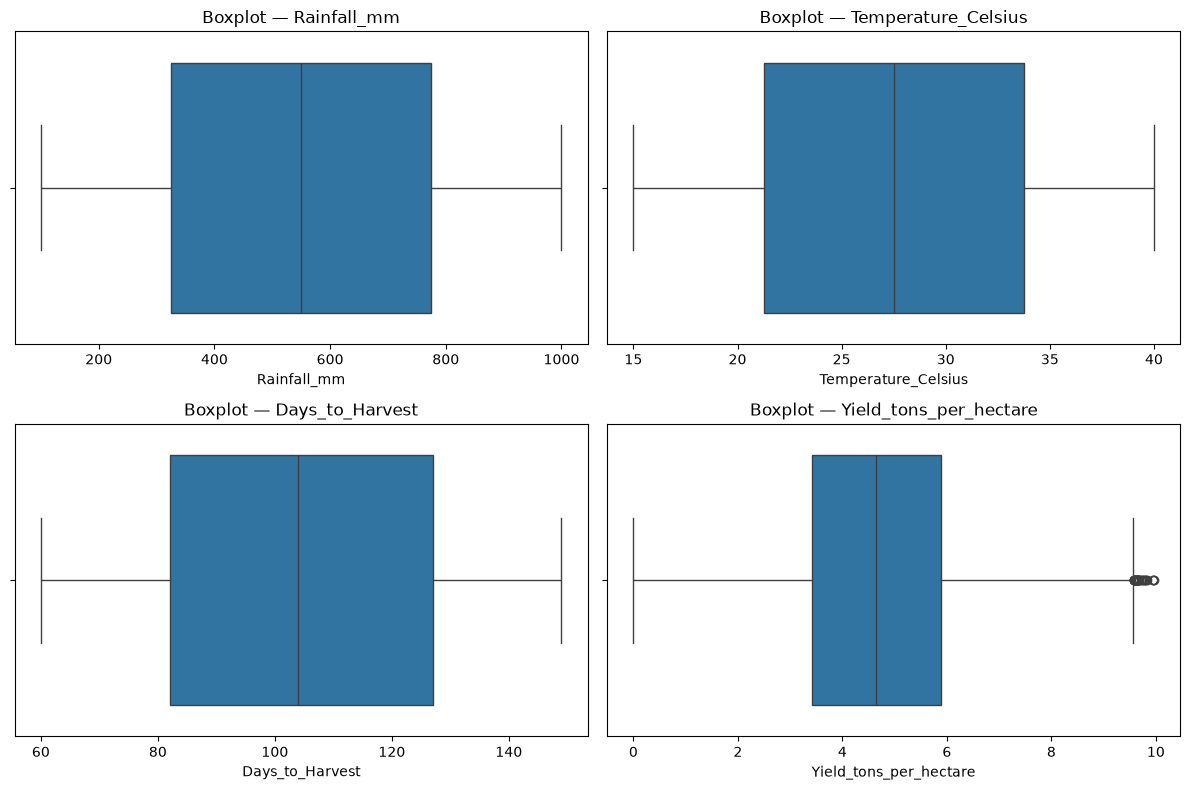

In [10]:
numeric_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x=data[col], ax=ax)
    ax.set_title(f"Boxplot — {col}")

plt.tight_layout()
plt.show()

---

Detected outliers in `Yield_tons_per_hectare` column, as their values slightly exceed the upper threshold and do not represent critical anomalies, we will keep them to ensures the integrity of the dataset and preserves important information for analysis.
For the remaining columns, no significant outliers were detected, and the data were kept intact.

--- 

In [42]:
data.to_csv("../../data/processed_data/yield_agriculture.csv",encoding='utf-8', index=False)

## 2.EDA

### 1. Yield distribution
Distribution of data in the Yield_tons_per_hectare column.

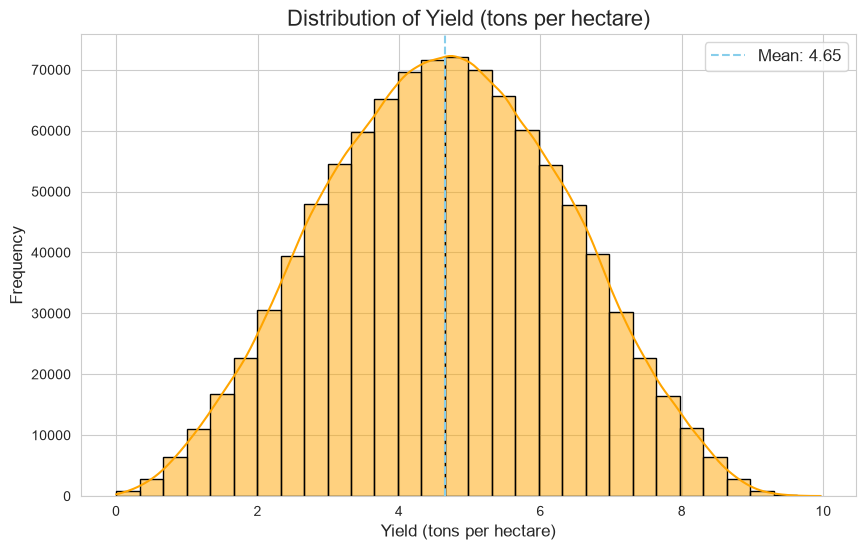

In [11]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(data['Yield_tons_per_hectare'], bins=30, kde=True, color="orange", edgecolor="black")
plt.axvline(data['Yield_tons_per_hectare'].mean(), color='skyblue', linestyle='--', linewidth=1.5, label=f"Mean: {data['Yield_tons_per_hectare'].mean():.2f}")

plt.title("Distribution of Yield (tons per hectare)", fontsize=16)
plt.xlabel("Yield (tons per hectare)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12);

### 2. Yield vs Region
**Identify the regions with the highest and lowest crop yields**

In [12]:
data.pivot_table(index='Region', 
                  values=['Yield_tons_per_hectare'],
                  aggfunc=['mean', 'median', 'min', 'max', 'count'])

,mean,median,min,max,count
,Yield_tons_per_hectare,Yield_tons_per_hectare,Yield_tons_per_hectare,Yield_tons_per_hectare,Yield_tons_per_hectare
Region,,,,,
East,4.646696,4.650415,0.000411,9.802534,249642
North,4.655298,4.659948,0.005619,9.949207,250112
South,4.649869,4.647228,0.000672,9.963372,250001
West,4.650497,4.651797,0.002143,9.952983,250014


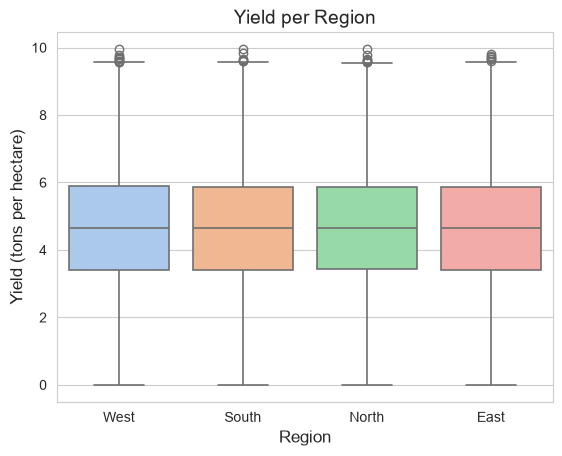

In [13]:
sns.boxplot(x=data['Region'], y=data['Yield_tons_per_hectare'], 
        palette='pastel',
        linewidth=1.2)

plt.title('Yield per Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Yield (tons per hectare)', fontsize=12);

---

1. **Uniform Yield Across Regions**:  
   The average yield (⚪`Yield_tons_per_hectare`⚪) is nearly identical across all regions, ranging from 4.65 to 4.66. This suggests consistent agricultural practices or similar environmental conditions across regions.  

2. **Presence of Extremely Low Yields**:  
   All regions show minimum values close to zero, which may indicate data errors, localized crop failures, or poor conditions in specific areas. This warrants further investigation.  

3. **Comparable Maximum Potential**:  
   Each region achieves similar maximum yields (~9.9 tons per hectare), reflecting a shared ceiling of agricultural productivity, possibly due to uniform access to technology or resources.  

---

### 3.Yield Vs Soil types Vs Weather condition
**Analyze the relationship between crop yield and soil types (Soil_Type) as well as weather conditions (Weather_Condition).**

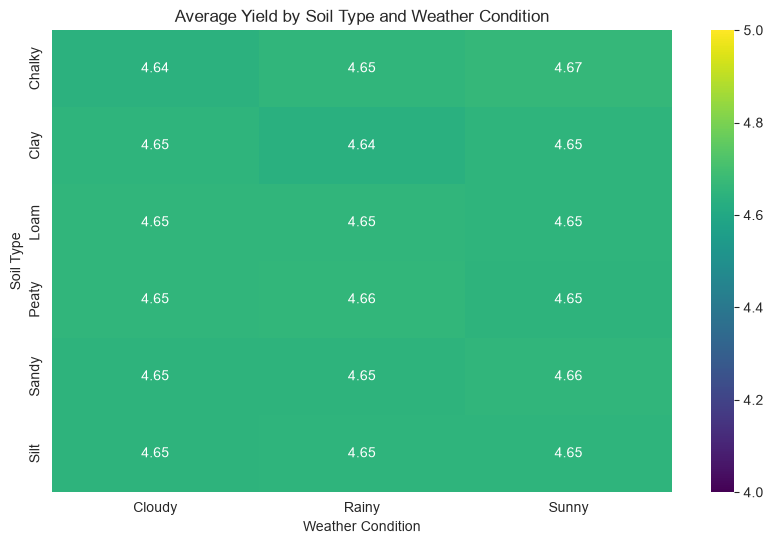

In [14]:
pivot_soil_table = data.pivot_table(
    values='Yield_tons_per_hectare', 
    index='Soil_Type', 
    columns='Weather_Condition', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_soil_table, annot=True, fmt=".2f", cmap="viridis", 
    vmin=4, 
    vmax=5)

plt.title("Average Yield by Soil Type and Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Soil Type");

---
**Key insights:**

1. **Minimal Impact of Soil Type and Weather Conditions**: The average yield values for different soil types and weather conditions vary only slightly, ranging between **4.63 and 4.67**. This indicates that neither factor significantly influences yield.

2. **Lack of Distinct Patterns**: There are no clear trends linking specific soil types or weather conditions to higher or lower yields. For example, yields under `Rainy`, `Cloudy`, and `Sunny` conditions are nearly identical across all soil types.
---

### 4. Yield Vs crops

#### 1.Yield distribution by crop
Crops distribution

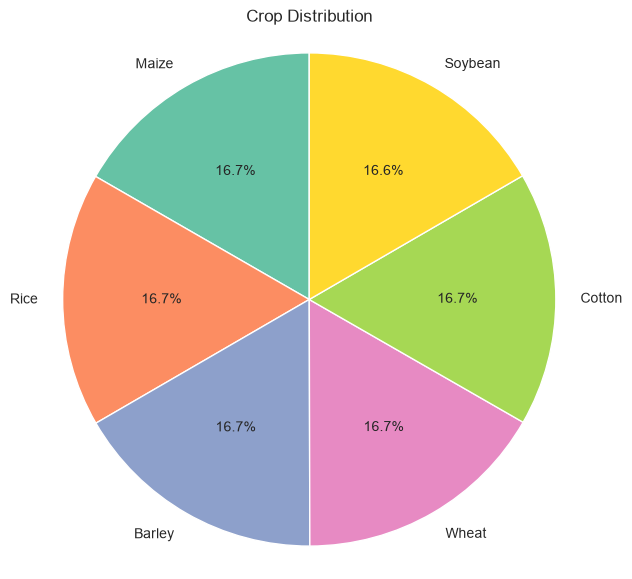

In [15]:
crop_counts = data["Crop"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    crop_counts,
    labels=crop_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(crop_counts)),
)
plt.title("Crop Distribution")
plt.axis("equal")  # keeps it a circle, not an oval
plt.show()

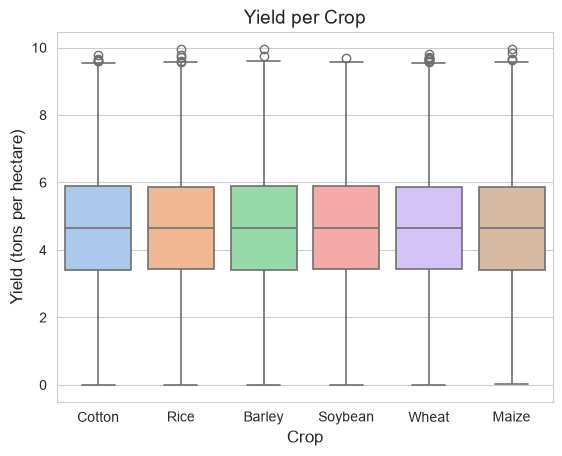

In [16]:
sns.boxplot(x=data['Crop'], y=data['Yield_tons_per_hectare'], 
        palette='pastel',
        linewidth=1.2)

plt.title('Yield per Crop', fontsize=14)
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Yield (tons per hectare)', fontsize=12);

**Yield distribution by crop** shows absence of variability across crops, with potential outliers visible.

#### 2. Yield Vs Rainfull & Temperature per crop
Examine the impact of rainfall (Rainfall_mm) and temperature (Temperature_Celsius) on crop yield for each type of crop.

In [17]:
correlation_by_crop = data.groupby('Crop')[['Rainfall_mm', 'Temperature_Celsius', 'Yield_tons_per_hectare']].corr().round(3)
correlation_by_crop

Rainfall_mm  Temperature_Celsius  \
Crop                                                               
Barley  Rainfall_mm                   1.000                0.002   
        Temperature_Celsius           0.002                1.000   
        Yield_tons_per_hectare        0.765                0.089   
Cotton  Rainfall_mm                   1.000               -0.000   
        Temperature_Celsius          -0.000                1.000   
        Yield_tons_per_hectare        0.765                0.086   
Maize   Rainfall_mm                   1.000                0.001   
        Temperature_Celsius           0.001                1.000   
        Yield_tons_per_hectare        0.765                0.085   
Rice    Rainfall_mm                   1.000               -0.000   
        Temperature_Celsius          -0.000                1.000   
        Yield_tons_per_hectare        0.765                0.082   
Soybean Rainfall_mm                   1.000               -0.001   
        Temperature_Celsius          -0.001                1.000   
        Yield_tons_per_hectare        0.763                0.087   
Wheat   Rainfall_mm                   1.000               -0.003   
        Temperature_Celsius          -0.003                1.000   
        Yield_tons_per_hectare        0.764                0.082   

                                Yield_tons_per_hectare  
Crop                                                    
Barley  Rainfall_mm                              0.765  
        Temperature_Celsius                      0.089  
        Yield_tons_per_hectare                   1.000  
Cotton  Rainfall_mm                              0.765  
        Temperature_Celsius                      0.086  
        Yield_tons_per_hectare                   1.000  
Maize   Rainfall_mm                              0.765  
        Temperature_Celsius                      0.085  
        Yield_tons_per_hectare                   1.000  
Rice    Rainfall_mm                              0.765  
        Temperature_Celsius                      0.082  
        Yield_tons_per_hectare                   1.000  
Soybean Rainfall_mm                              0.763  
        Temperature_Celsius                      0.087  
        Yield_tons_per_hectare                   1.000  
Wheat   Rainfall_mm                              0.764  
        Temperature_Celsius                      0.082  
        Yield_tons_per_hectare                   1.000

#### Rainfall vs Yield, per crop

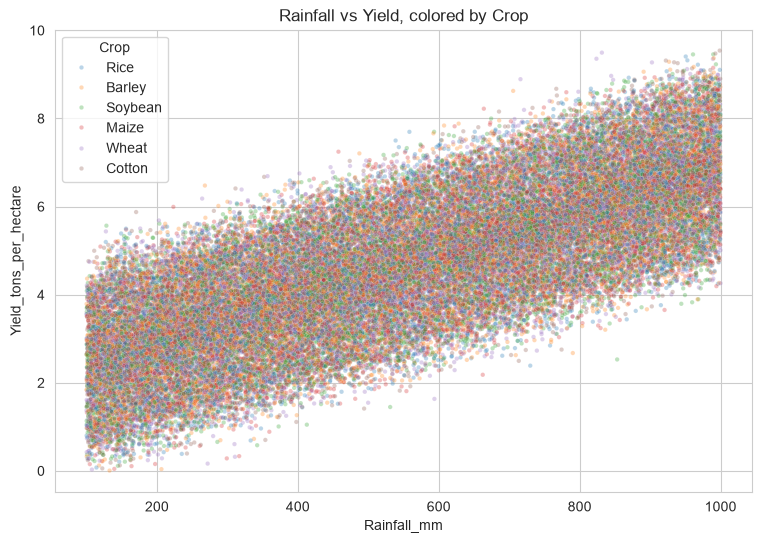

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=data.sample(50_000, random_state=42),  # subsample for readability/speed
    x="Rainfall_mm",
    y="Yield_tons_per_hectare",
    hue="Crop",
    alpha=0.3,
    s=10,
)
plt.title("Rainfall vs Yield, colored by Crop")
plt.show()

#### Temperature vs Yield, per crop

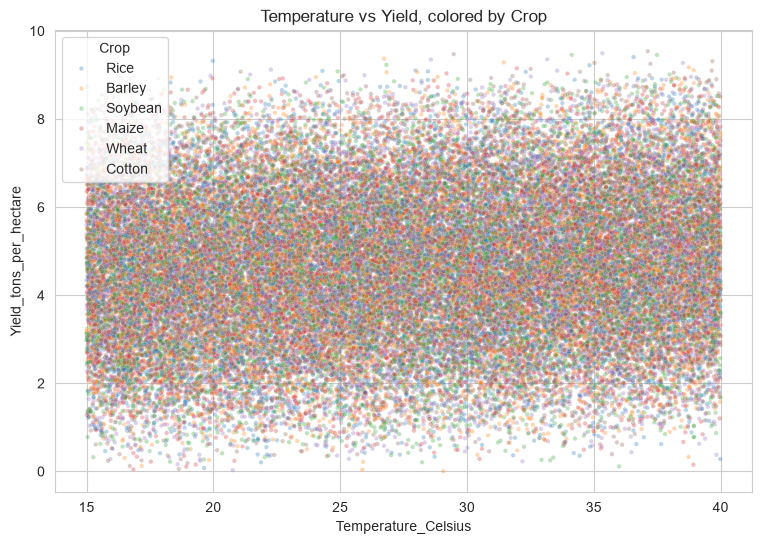

In [19]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=data.sample(50_000, random_state=42),  # subsample for readability/speed
    x="Temperature_Celsius",
    y="Yield_tons_per_hectare",
    hue="Crop",
    alpha=0.3,
    s=10,
)
plt.title("Temperature vs Yield, colored by Crop")
plt.show()

---
From all the above we can conclude :
1. **Rainfall has a strong positive correlation with crop yield** (approximately 0.765 for all crops), indicating its significant impact on productivity.  
2. **Temperature shows minimal correlation with crop yield** (around 0.08-0.09), suggesting a negligible influence across all crops.  
3. **Correlation patterns are consistent across all crop types**, highlighting similar weather-related dependencies regardless of the crop.

---

#### 3. Yield Vs Days to Harvest per crop

In [20]:
data.pivot_table(index = ['Crop'], values = ['Days_to_Harvest', 'Temperature_Celsius', 'Rainfall_mm', 'Yield_tons_per_hectare'],
               aggfunc = 'mean')

,Days_to_Harvest,Rainfall_mm,Temperature_Celsius,Yield_tons_per_hectare
Crop,,,,
Barley,104.427465,549.686490,27.502574,4.648864
Cotton,104.531625,549.995080,27.528243,4.651918
Maize,104.538292,549.291189,27.478547,4.642513
Rice,104.499778,550.605746,27.499657,4.651849
Soybean,104.457139,550.559846,27.510413,4.654701
Wheat,104.516491,550.330008,27.517093,4.653722


---

1. **Days to Harvest:** Nearly identical across Crop (~104.5 days), indicating no significant crop impact.
2. **Rainfall:** Minimal variation (~549–551 mm), suggesting similar climatic conditions.
3. **Temperature:** Stable across crops (~27.5°C) with negligible differences.
4. **Yield:** Slightly higher in **Soybean (4.654 tons/ha)**, but overall consistent across crops.

**Conclusion:** Crops share similar environmental conditions and yield levels, indicating uniform agricultural performance. 

---

### 5. Yield Vs Fertilizer & Irrigation

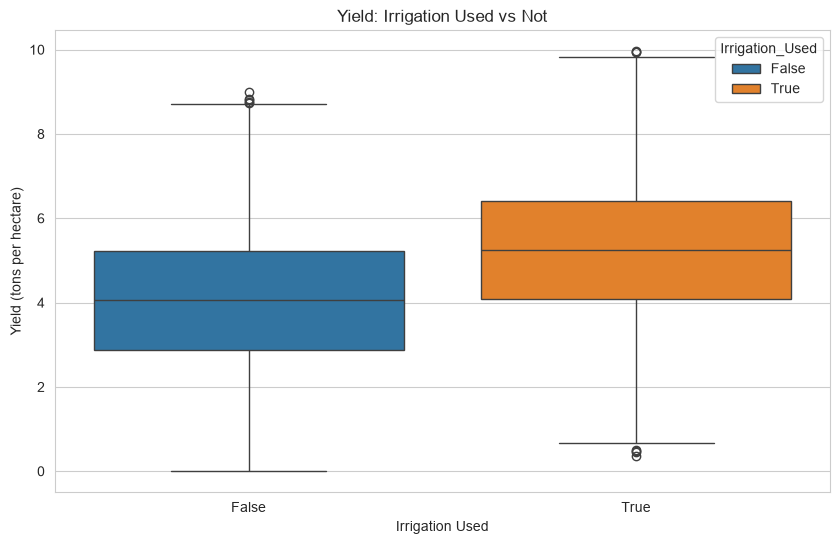

In [21]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Irrigation_Used', y='Yield_tons_per_hectare', hue="Irrigation_Used", data=data)
ax.set_title('Yield: Irrigation Used vs Not')
ax.set_xlabel('Irrigation Used')
ax.set_ylabel('Yield (tons per hectare)')

plt.show()

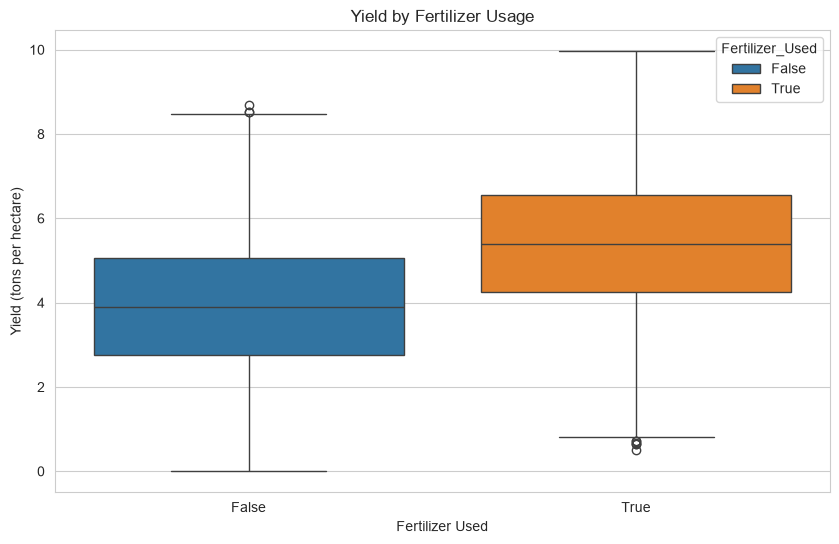

In [22]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Fertilizer_Used', y='Yield_tons_per_hectare', hue="Fertilizer_Used", data=data)
ax.set_title('Yield by Fertilizer Usage')
ax.set_xlabel('Fertilizer Used')
ax.set_ylabel('Yield (tons per hectare)')

plt.show()

In [23]:
by_both = data.groupby(['Fertilizer_Used', 'Irrigation_Used'])['Yield_tons_per_hectare'].agg(['mean', 'median', 'min', 'max'])
by_both

mean    median       min       max
Fertilizer_Used Irrigation_Used                                        
False           False            3.305905  3.302894  0.000411  7.337233
                True             4.499366  4.498009  0.371804  8.683593
True            False            4.799632  4.802903  0.498752  8.986859
                True             5.999009  5.999967  1.871298  9.963372

---
**Combined Analysis (`Fertilizer_Used` and `Irrigation_Used`)**:
   - The lowest yield occurs without both fertilizers and irrigation (average 3.31).
   - Either fertilizers (4.80) or irrigation (4.50) alone improves yield significantly.
   - The highest yield is achieved when both fertilizers and irrigation are used together (average 6.00, maximum 9.96).

**Conclusion**: Fertilizers and irrigation complement each other, with the combined use yielding the best results.

---

### 6.Data correlation

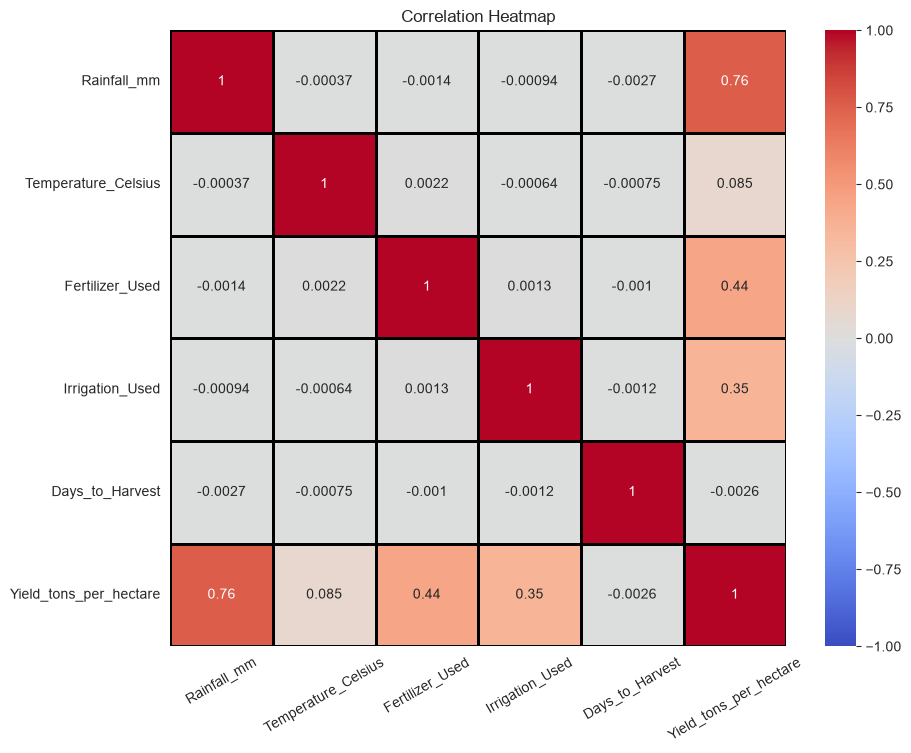

In [24]:
df_corr = data.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, annot=True, vmin=-1, vmax=1, center= 0, cmap= 'coolwarm', linewidths=2, linecolor='black', square=True)
plt.title('Correlation Heatmap')
plt.xticks(rotation=30);

---
From the **correlation heatmap**, we notice that:

1. **Strong correlation between `Rainfall_mm` and `Yield_tons_per_hectare` (0.764):** Higher rainfall is strongly associated with increased yield.

2. **Moderate correlation with yield:**  
   - `Fertilizer_Used` (0.442) improves yield.  
   - `Irrigation_Used` (0.353) Irrigation is linked to higher yield, making it particularly important in regions with low rainfall.

3. **Weak or negligible correlations:**  
   - `Days_to_Harvest` (-0.003) and `Temperature_Celsius` (0.085) have minimal direct impact on yield.
4. **Almost all predictor variables are independent:**
   Each variable contributes independent information. The explanation of that: dataset is synthetically generated with each field drawn independently, rather than reflecting real agronomic relationships (where rainfall and irrigation, for instance, would typically be correlated in real-world data). 
--- 

**Summary of the EDA:**

 1. **Missing Values and Duplicates**:
   - No missing values are present in the dataset.
   - No duplicate rows were found.

 2. **Outliers**:
   - Delete 231 rows having negative values for `Yield_tons_per_hectare`. These likely indicate erroneous data, as  yields should be non-negative.

 3. **Statistical Summary**:
   - **Rainfall (mm)**: Ranges from 100 mm to 999 mm, with a mean of ~550 mm.
   - **Temperature (Celsius)**: Values range from 15°C to 40°C, with an average around 27.5°C.
   - **Days to Harvest**: Range from 60 to 149 days, with a mean of ~104 days.
   - **Yield (tons per hectare)**: Average is 4.65 tons/hectare, with strong correlation with Rainfull.


## 3.PCA

**Principal  Component  Analysis  (PCA)** is applied to reduce the dimensionality of the dataset and   highlight   the   most   relevant   variables   that preserved 95% of the total variance, reducing the redundancy    between    correlated    features    while preserving important information for model training 

* We exclude Yield_tons_per_hectare from the PCA inputs on purpose:
PCA should summarize the PREDICTORS' structure, not the target itself.
We'll correlate the resulting components with yield afterward instead.
 

### 1. Fit PCA

In [25]:
# Convert booleans to 0/1 so they can be scaled alongside numeric features
data["Fertilizer_Used"] = data["Fertilizer_Used"].astype(int)
data["Irrigation_Used"] = data["Irrigation_Used"].astype(int)

target = data["Yield_tons_per_hectare"]

numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Days_to_Harvest",
]

X_numeric = data[numeric_features].copy()

# Standardize: PCA is scale-sensitive, and Rainfall_mm (hundreds) and
# Temperature_Celsius (tens) are on very different scales.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

**Verify if all column are centrid-reduit**

In [26]:
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4
mean,0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0


**PCA on numeric predictors (main analysis)**

In [27]:
pca = PCA(n_components=5)
pca_scores = pca.fit_transform(X_scaled)
# Explained variance per component
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i}: {var:.2%} explained, {cum:.2%} cumulative")

PC1: 20.06% explained, 20.06% cumulative
PC2: 20.05% explained, 40.12% cumulative
PC3: 20.02% explained, 60.13% cumulative
PC4: 19.94% explained, 80.08% cumulative
PC5: 19.92% explained, 100.00% cumulative


**The information is spread almost uniformly across all five variables. There is no strong redundancy, so PCA does not reduce the dimensionality effectively. To retain 80% of the variance, we still need 4 out of 5 components.**

### 2.Visualize PCA 

**Visualize explained variance (scree plot)**

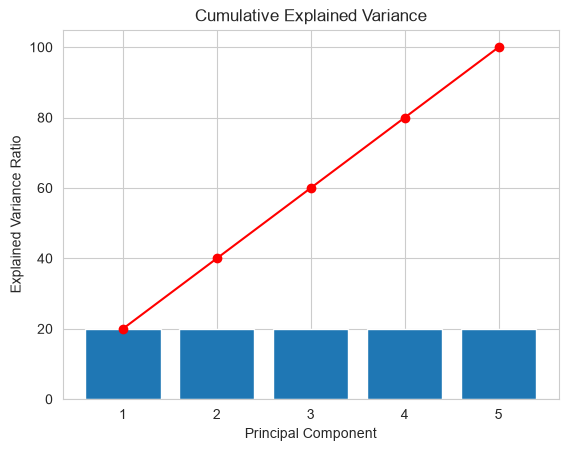

In [28]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree_cum = scree.cumsum().round()
x_list = range(1, 6)
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Cumulative Explained Variance")
plt.show(block=False)

**Which original variables drive each component**

In [29]:
pca_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=numeric_features,
)

print(pca_df.round(3))

                       PC1    PC2    PC3    PC4    PC5
Rainfall_mm         -0.247  0.710 -0.130  0.051  0.644
Temperature_Celsius  0.501  0.034 -0.611 -0.607  0.080
Fertilizer_Used      0.694 -0.069 -0.053  0.658  0.279
Irrigation_Used      0.360  0.034  0.770 -0.437  0.291
Days_to_Harvest     -0.277 -0.699 -0.119 -0.063  0.645


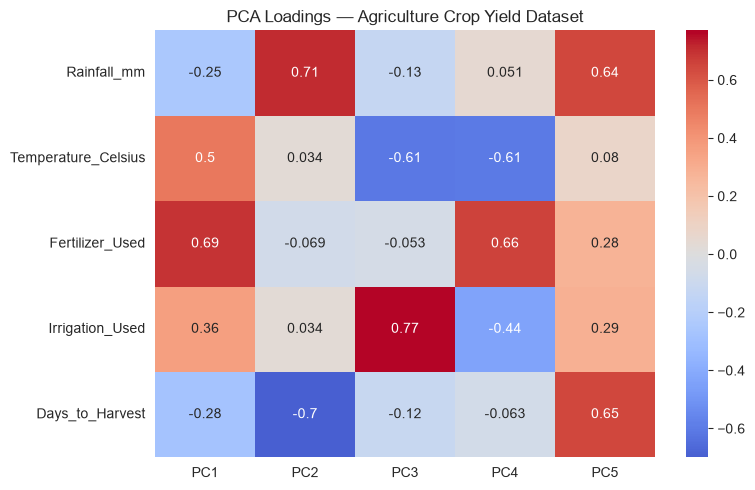

In [30]:
# Heatmap for the report / MLflow screenshot
plt.figure(figsize=(8, 5))
sns.heatmap(pca_df, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings — Agriculture Crop Yield Dataset")
plt.tight_layout()
plt.show()

* **PC1 20%** contrasts: high fertilizer use with higher temperatures against lower rainfall and fewer harvest days.
   This component mainly represents an input intensity / warm growing conditions axis.
* **PC2 20%** is almost entirely a contrast between wetter environments ,shorter harvest durations and drier environments longer harvest durations.
   This suggests rainfall and harvest duration are inversely related in the dataset.
* **PC3 20%** contrasts irrigated fields against hotter conditions.
   This may indicate that irrigation is more common in cooler-growing conditions.
* **PC4 19.94%** contrasts fertilizer & irrigation application against temperature.
  This is not necessarily causal—just a direction of variation in the data.
* **PC5 19.92%** combines higher rainfall with longer harvest periods.
  Unlike PC2, these variables now move together because each principal component is constrained to be orthogonal to the others.

### 3.Visualize Correlation circle

In [31]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Correlations graphe 

    Arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA
    x_y : list or tuple : list of Pca component to show [0,1] for Pca1, Pca2
    features : list or tuple : List of columns from the original dataframe
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('PCA{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('PCA{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Correlation circle (PCA{} et PCA{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

In [32]:
pca_df_t = pca_df.T
pca_df_t

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest
PC1,-0.246778,0.500985,0.693791,0.360248,-0.277472
PC2,0.710124,0.033802,-0.068857,0.033606,-0.699078
PC3,-0.129844,-0.610713,-0.052776,0.770179,-0.119202
PC4,0.051049,-0.607091,0.658352,-0.437482,-0.063374
PC5,0.644484,0.079634,0.278747,0.290733,0.645037


#### Correlation between variables and PCA1 & PCA2

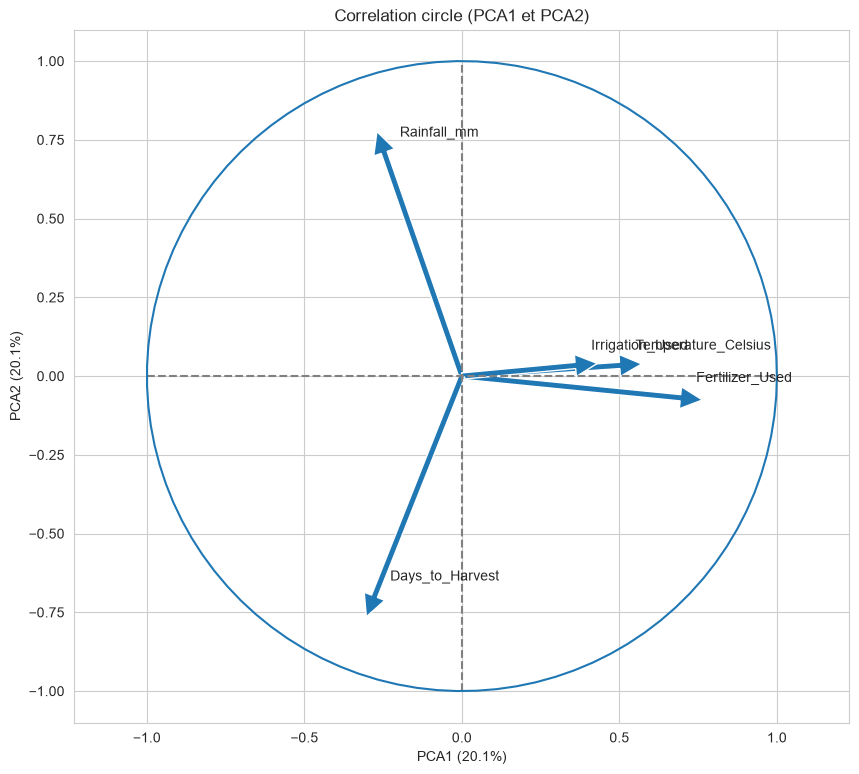

In [33]:
correlation_graph(x_y = (0,1), pca=pca, features=pca_df_t.columns)

#### Correlation between variables and PCA3 & PCA4

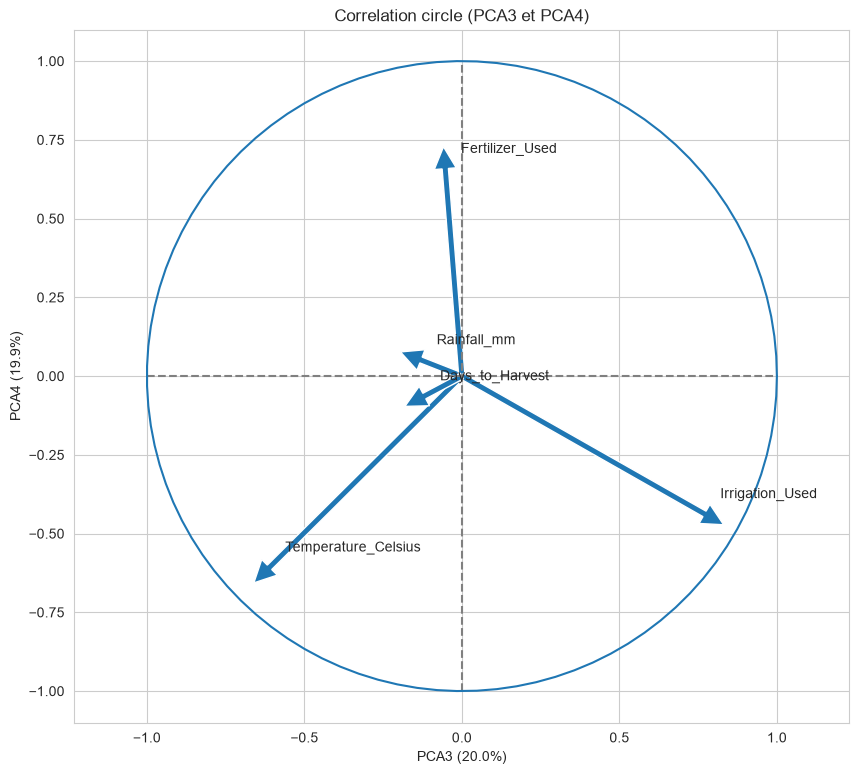

In [34]:
correlation_graph(x_y = (2,3), pca=pca, features=pca_df_t.columns)

**PCA analyse**
- All 5 numeric predictors (Rainfall_mm, Temperature_Celsius, Fertilizer_Used, Irrigation_Used, Days_to_Harvest) explain almost exactly ~20% of variance each, across all 5 components.
- This means these variables are statistically independent of one another — there's no single latent factor dominates the dataset. Each carries its own distinct piece of information.
- **PCA is designed for continuous variables**. Next step, try Factor Analysis of Mixed Data (FAMD) would be more appropriate, as it can naturally handle both continuous variables (rainfall, temperature, days to harvest) and categorical/binary variables (fertilizer and irrigation).

## 4.Factor Analysis of Mixed Data (FMAD)
**Factor Analysis of Mixed Data (FAMD)** is an exploratory dimensionality reduction technique designed for datasets containing both numerical and categorical variables. It was introduced by Pagès (2004) as an extension of Principal Component Analysis (PCA).
Unlike PCA, which can only handle continuous numerical variables, FAMD simultaneously analyzes quantitative variables (e.g., rainfall and temperature) and qualitative variables (e.g., crop type, soil type, region) within the same framework.
The objective of FAMD is to summarize the information contained in the dataset into a smaller number of latent dimensions while preserving as much variability as possible.

**Why FAMD?**
- The dataset used in this project contains variables of different types. Applying PCA directly would require converting all categorical variables into dummy variables using one-hot encoding. This often leads to a large number of binary variables and may distort the analysis because categorical variables are treated as continuous.
- FAMD avoids this limitation by treating each variable according to its nature.
  
**FAMD steps:**
FAMD combines the principles of two classical multivariate methods:
* Principal Component Analysis (PCA) for numerical variables.
* Multiple Correspondence Analysis (MCA) for categorical variables.
  
The procedure consists of the following steps.
- Standardization of numerical variables: Each numerical variable is centered and scaled
- Transformation of categorical variables: Categorical variables are transformed into indicator (dummy) variables.
- Balancing variable influence: One important characteristic of FAMD is that each original variable contributes approximately the same total weight, regardless of whether it is numerical or categorical.
- Construction of principal dimensions: After preprocessing, FAMD computes new orthogonal axes (components).

In [35]:
import prince

In [36]:
# FAMD works directly on a mix of numeric and categorical columns —
# no manual one-hot encoding needed, and no manual scaling either
# (prince handles the internal normalization for each type).

famd_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "Region",
    "Soil_Type",
    "Crop",
    "Weather_Condition",
    "Fertilizer_Used",
    "Irrigation_Used",
]

# Booleans read back in as True/False are fine as categorical for FAMD;
# cast explicitly to make the categorical nature unambiguous to prince.
X_famd = data[famd_features].copy()
X_famd["Fertilizer_Used"] = X_famd["Fertilizer_Used"].astype(str)
X_famd["Irrigation_Used"] = X_famd["Irrigation_Used"].astype(str)
X_famd["Days_to_Harvest"] = X_famd["Days_to_Harvest"].astype(float)
# NOTE: FAMD on 1M rows can be memory/compute heavy since it involves
# an underlying correspondence-analysis step on categoricals.
# If it's too slow, take a representative random sample first, e.g.:
# X_famd = X_famd.sample(n=100_000, random_state=42)

In [37]:
print(X_famd.dtypes)

Rainfall_mm            float64
Temperature_Celsius    float64
Days_to_Harvest        float64
Region                  object
Soil_Type               object
Crop                    object
Weather_Condition       object
Fertilizer_Used         object
Irrigation_Used         object
dtype: object


In [38]:
famd = prince.FAMD(n_components=5, random_state=42)
famd = famd.fit(X_famd)

# Explained variance per dimension
print(famd.eigenvalues_summary)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              1.006         5.03%                      5.03%
1              1.004         5.02%                     10.05%
2              1.004         5.02%                     15.07%
3              1.002         5.01%                     20.08%
4              1.002         5.01%                     25.09%


**5% the explained variance**, comes from that in FAMD, every categorical variable is expanded into multiple indicator (dummy) variables.
Internally, this becomes many binary columns. The total inertia is therefore much larger than the number of original variables, so each component explains a relatively small percentage of the total. This is common in FAMD with several categorical variables.

In [39]:
#famd

In [40]:
# Row coordinates (like PCA scores)
#row_coords = famd.row_coordinates(X_famd)
#row_coords.head()

#### Contribution of each varaible in FAMD component

In [41]:
# Column contributions: which original variables (numeric AND categorical)
# drive each FAMD dimension
col_contrib = famd.column_contributions_
print(col_contrib.round(3))

component                0      1      2      3      4
variable                                              
Rainfall_mm          0.213  0.020  0.092  0.057  0.009
Temperature_Celsius  0.009  0.176  0.014  0.032  0.013
Days_to_Harvest      0.073  0.006  0.005  0.213  0.042
Crop                 0.117  0.307  0.256  0.173  0.371
Fertilizer_Used      0.009  0.164  0.000  0.142  0.000
Irrigation_Used      0.000  0.001  0.002  0.017  0.175
Region               0.290  0.026  0.075  0.050  0.187
Soil_Type            0.219  0.252  0.377  0.289  0.080
Weather_Condition    0.070  0.049  0.179  0.027  0.124


**Contribution explained as follow:**
- The first dimension is mainly associated with geographical and environmental conditions. It is driven by the combination of region, soil type, and rainfall.
- The second dimension primarily reflects crop characteristics, with additional influence from soil type and growing conditions (temperature and fertilizer use).
- The third one emphasizes the relationship between soil type and crop selection, with weather condition also contributing.
- The fourth component captures variation related to harvest duration, influenced by soil type and crop.
- The last dimension is mainly driven by crop type, with regional differences and irrigation practices also contributing.

## 5.Conclusion

**The FAMD performed on the agricultural dataset showed that:**

* Crop contributes strongly to several dimensions, indicating that crop type is one of the main factors structuring the observations.
* Soil type also contributes substantially, suggesting that different crops are associated with different soil conditions.
* Region and Rainfall mainly define the first environmental dimension.
* Temperature, fertilizer use, and irrigation have moderate contributions.

These results indicate that the variability of the dataset is explained by a combination of environmental conditions, crop characteristics, and soil properties rather than by a single dominant factor.

---
**Final conclusions**
Principal Component and Factor Analysis of Mixed Data were applied to identify latent groupings among yield-driving variables. Both methods showed no dominant composite factor — each variable contributes largely independent information to yield — indicating that all nine variables should be considered individually as direct yield drivers rather than through a reduced set of components.

---